In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
min_fibers = 100

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_noveto_20221031.fits'))
# cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/daily/lss_daily_y1_lrg_full_20221031.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

5235371


In [5]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [6]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

# mask = cat['EBV']<0.1
# print(np.sum(mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

print(len(cat))

FIBERSTATUS    2444313 2791058 0.46688439081012595
No data    0 2791058 0.0
LRG mask 2535376 255682 0.09160755527115524
Remove QSO targets 2510536 24840 0.009797363389098895
Remove objects classified as QSOs: 2478965 31571 0.012575402224863535
Remove objects classified as STARs: 2470314 8651 0.0034897628647439557
Min depth    109509 2360805 0.04432999205768983
0.012358072776023432
2360805


In [7]:
# # WISE and MEDIUM masks
# maskbits = [8, 9, 11]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
# cat = cat[mask_clean]

In [8]:
mask_gal = cat['SPECTYPE']=='GALAXY'
mask_qso = cat['SPECTYPE']=='QSO'
cat['Z'][mask_gal].max()

1.6997426534895044

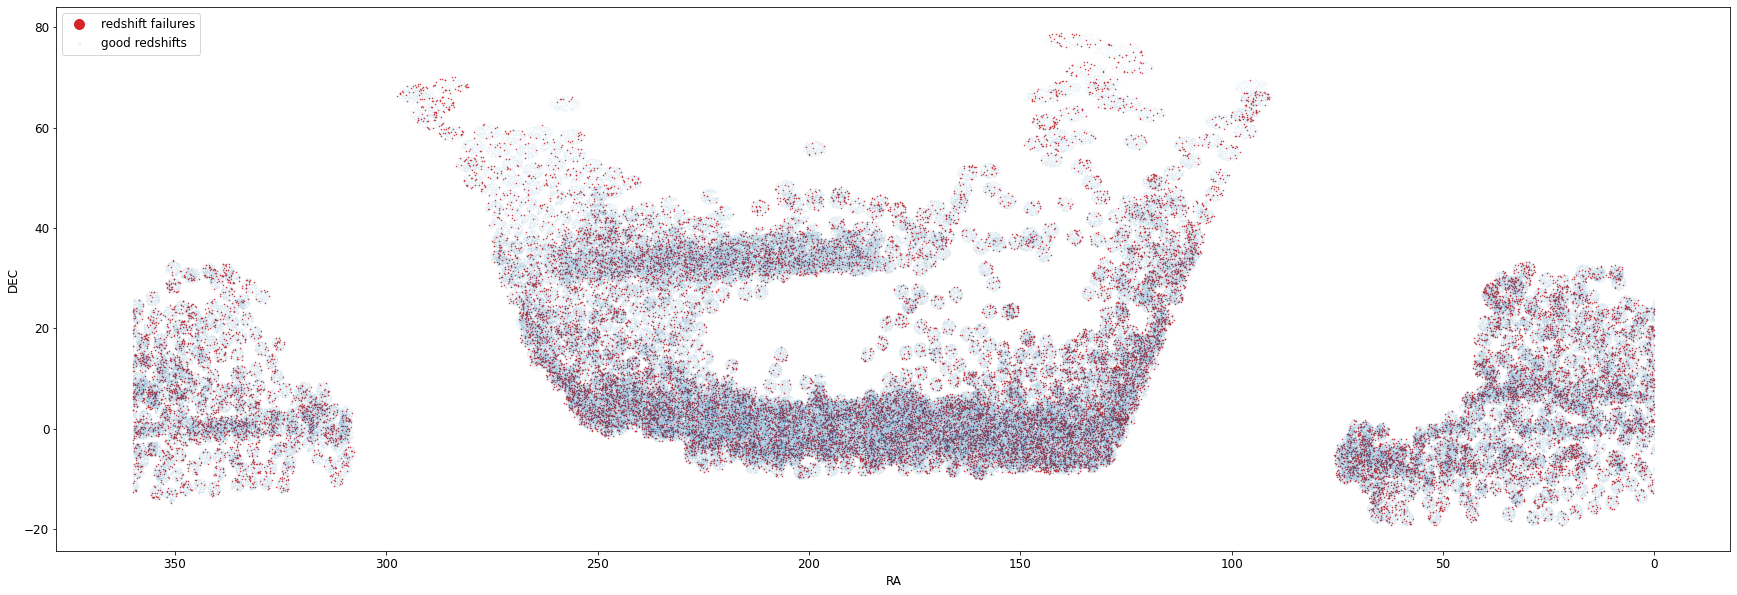

In [9]:
plt.figure(figsize=(30, 10))
plt.plot(cat['RA'][~cat['q']], cat['DEC'][~cat['q']], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['RA'][cat['q']], cat['DEC'][cat['q']], 'C0.', ms=.3, alpha=0.05, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
# plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

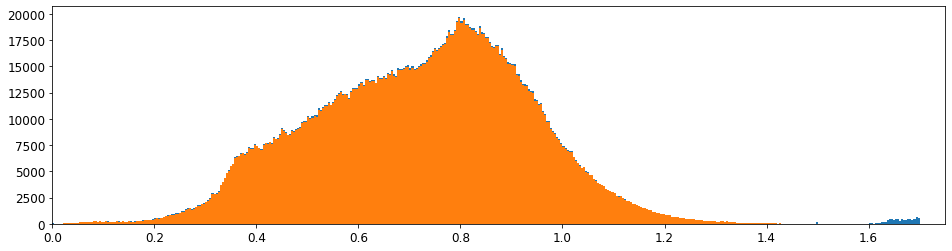

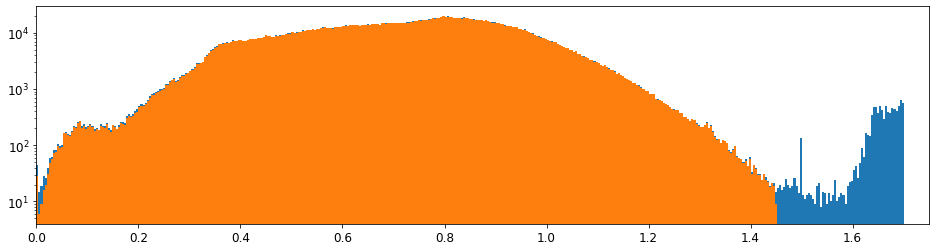

In [10]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][mask_quality], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

plt.figure(figsize=(16, 4))
plt.hist(cat['Z'], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][mask_quality], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

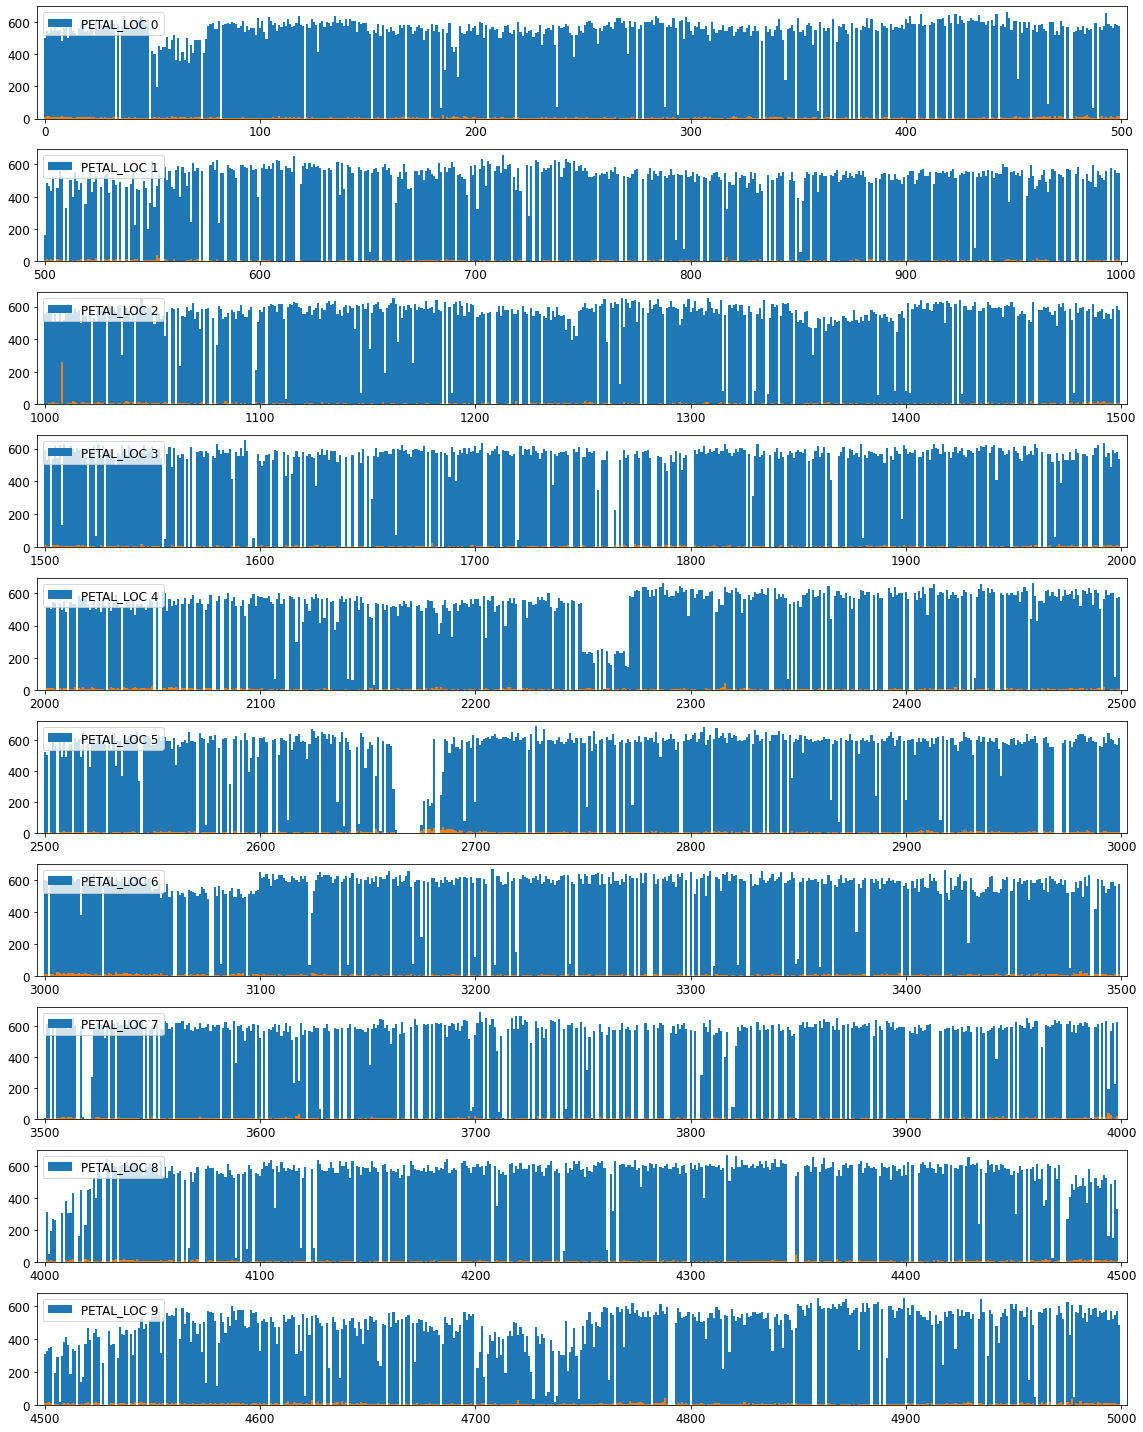

In [11]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-3, fiber_max+3)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [12]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~mask_quality], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1877,576,0,0.0,0.0017346034155500288
4000,1,0,0.0,0.0
2236,10,0,0.0,0.09486832980505137
3986,3,0,0.0,0.2721655269759087
1336,65,0,0.0,0.015265813487902579
1330,80,0,0.0,0.01242162932146987
2277,3,0,0.0,0.2721655269759087
2345,68,0,0.0,0.014597350372565921
1315,81,0,0.0,0.01226923444444329


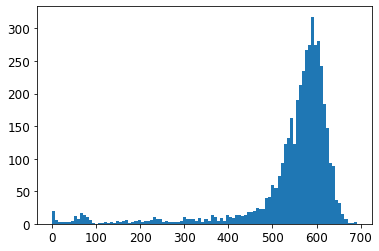

In [13]:
plt.hist(fiberstats['n_tot'], 100);

In [14]:
tmp = fiberstats.copy()
tmp.sort('frac_fail', reverse=True)
mask = tmp['n_tot']>min_fibers
tmp[mask][:30]

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1008,511,262,0.512720156555773,0.022111538885675793
3994,191,38,0.19895287958115182,0.028886003720304088
2679,175,25,0.14285714285714285,0.026452002850644328
3618,246,35,0.14227642276422764,0.022272685730120038
2678,217,28,0.12903225806451613,0.02275727811298898
2676,209,24,0.11483253588516747,0.02205322233258611
2685,396,40,0.10101010101010101,0.015143010230748743
2684,248,23,0.09274193548387097,0.018419492314482835
552,466,38,0.0815450643776824,0.012677534695331536


In [15]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

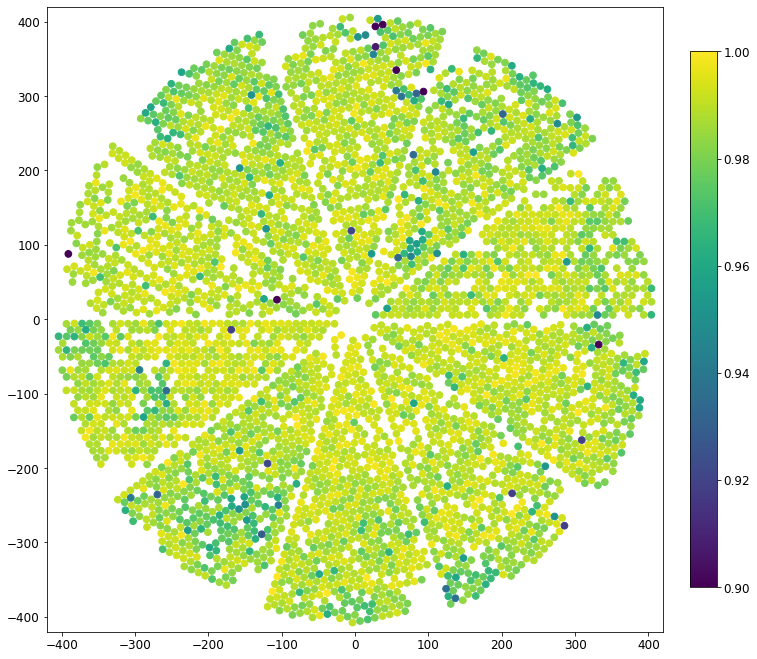

In [16]:
mask = fiberstats['n_tot']>min_fibers

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.9, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

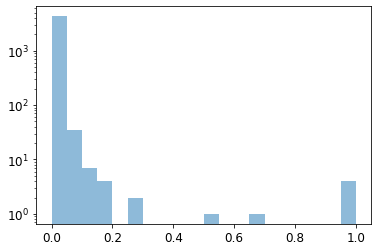

In [17]:
# mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers))
# mask_bad = (fiberstats['n_tot']>30) & np.in1d(fiberstats['FIBER'], bad_fibers)

# plt.hist(fiberstats['frac_fail'][mask_good], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.hist(fiberstats['frac_fail'][mask_bad], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.show()

plt.hist(fiberstats['frac_fail'], 20, log=True, alpha=0.5)
plt.show()

__Flag the worst fibers__

In [18]:
# frac_fail_threshold = np.percentile(fiberstats['frac_fail'], 99.5)
frac_fail_threshold = 0.05

print(frac_fail_threshold)
mask_threshold = fiberstats['frac_fail']>=frac_fail_threshold
print(np.sum(mask_threshold), np.sum(mask_threshold)/len(mask_threshold))
print(np.mean(fiberstats['frac_fail'][mask_threshold]), np.mean(fiberstats['frac_fail']), np.mean(fiberstats['frac_fail'][~mask_threshold]))
print(np.sum(fiberstats['n_fail'][mask_threshold])/np.sum(fiberstats['n_fail']))

bad_fibers = fiberstats['FIBER'][mask_threshold].copy()
print(len(bad_fibers))

0.05
54 0.012474012474012475
0.1783469396940358 0.014360739477505647 0.012289334843191582
0.037463581833761785
54


__Add statistical outliers__

In [19]:
mask = np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate of bad fibers: {:.4f}%'.format(100*np.sum(mask_quality[mask])/np.sum(mask)))
mask = ~np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate of good fibers: {:.4f}%'.format(100*np.sum(mask_quality[mask])/np.sum(mask)))

Failure rate of bad fibers: 90.2096%
Failure rate of good fibers: 98.8048%


In [20]:
mask = ~np.in1d(cat['FIBER'], bad_fibers)
average_success_rate = np.sum(mask_quality[mask])/np.sum(mask)
print(average_success_rate)

mask = fiberstats['n_tot']>min_fibers
mask &= fiberstats['frac_fail'] - 3.5*fiberstats['frac_fail_err'] > (1-average_success_rate)
print(np.sum(mask))
mask &= ~np.in1d(fiberstats['FIBER'], bad_fibers)
print(np.sum(mask))
fiberstats[mask]

0.9880483869663493
32
11


FIBER,n_tot,n_fail,frac_fail,frac_fail_err,MEAN_X,MEAN_Y
int32,int64,int64,float64,float64,float64,float64
961,469,22,0.046908315565031986,0.009763506908657443,259.3599548339844,-197.54962158203125
2182,477,22,0.04612159329140461,0.009603719571570407,302.5920715332031,271.2300109863281
4638,462,23,0.049783549783549784,0.010118897921197119,-149.84178161621094,-248.98793029785156
4613,519,24,0.046242774566473986,0.009218434697882803,-147.60975646972656,-269.90277099609375
2050,552,24,0.043478260869565216,0.00867988488592055,161.24124145507812,224.47801208496094
3033,613,25,0.040783034257748776,0.00798854996004146,-278.5029296875,285.0007019042969
4624,541,27,0.04990757855822551,0.009361976441158461,-158.31671142578125,-255.18594360351562
2687,593,27,0.045531197301854974,0.008560675945135987,31.01611328125,403.9189453125
1680,592,27,0.04560810810810811,0.008574791048485155,288.6567687988281,77.19052124023438


In [39]:
bad_fibers = np.unique(np.concatenate([fiberstats['FIBER'][mask], bad_fibers]))
print(len(bad_fibers))

Total number of bad fibers: 65


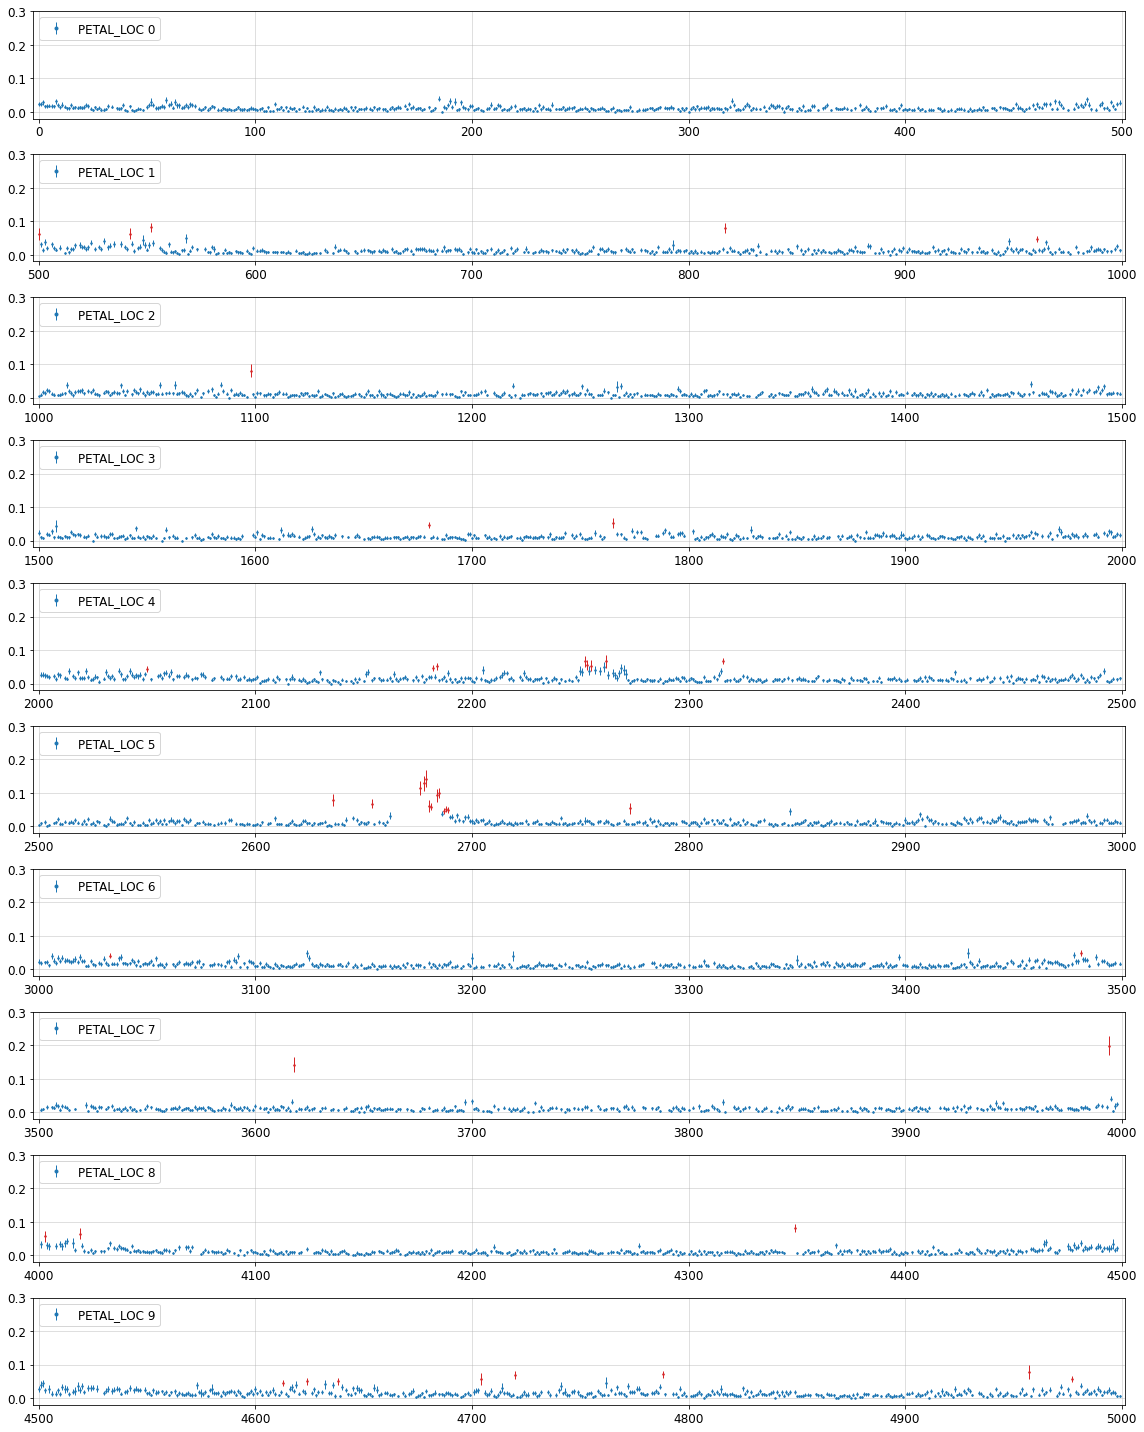

In [22]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (fiberstats['FIBER']>fiber_min) & (fiberstats['FIBER']<fiber_max)
    mask &= (fiberstats['n_tot']>min_fibers)
    mask_good = mask & (~np.in1d(fiberstats['FIBER'], bad_fibers))
    mask_bad = mask & np.in1d(fiberstats['FIBER'], bad_fibers)
    # plt.figure(figsize=(16, 2))
    ax[index].errorbar(fiberstats['FIBER'][mask_good], fiberstats['frac_fail'][mask_good], 
                       yerr=(np.clip(fiberstats['frac_fail_err'][mask_good], None, fiberstats['frac_fail'][mask_good]), fiberstats['frac_fail_err'][mask_good]),
                       color='C0', fmt='.', ms=3, elinewidth=1, label='PETAL_LOC {}'.format(index))
    ax[index].errorbar(fiberstats['FIBER'][mask_bad], fiberstats['frac_fail'][mask_bad],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad], None, fiberstats['frac_fail'][mask_bad]), fiberstats['frac_fail_err'][mask_bad]),
                   color='C3', fmt='.', ms=3, elinewidth=1)
    ax[index].grid(alpha=0.5)
    ax[index].set_yticks([0., 0.1, 0.2, 0.3], minor=False)
    ax[index].set_ylim(-0.02, 0.3)
    ax[index].set_xlim(fiber_min-2, fiber_max+2)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

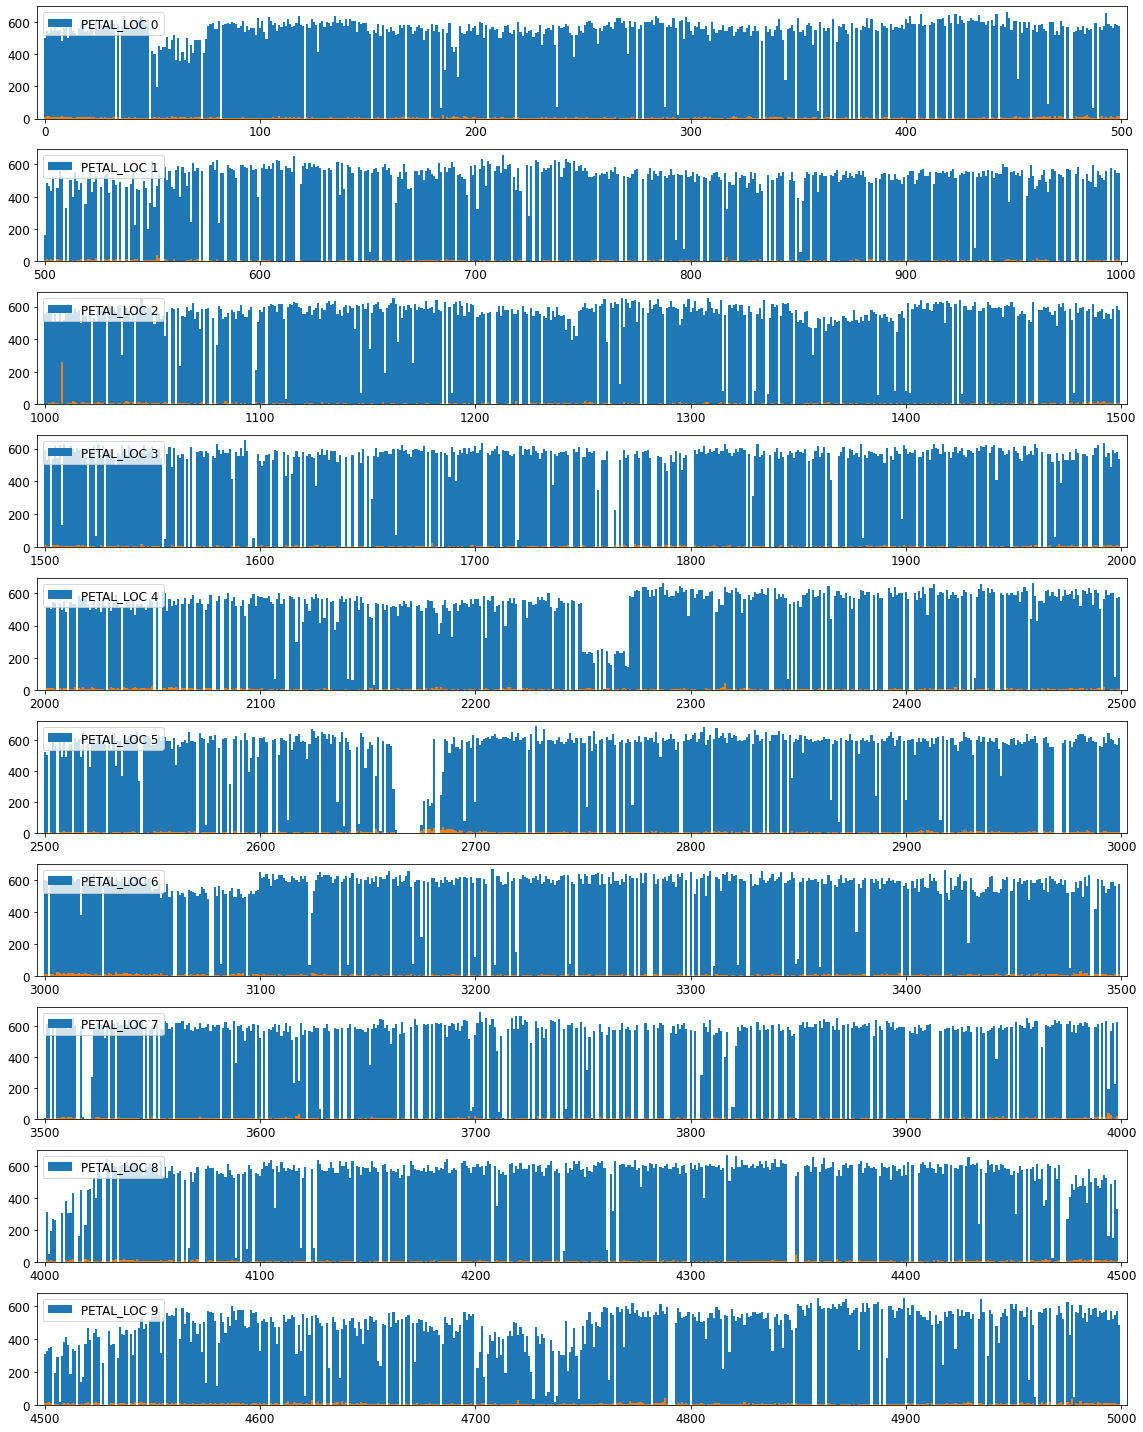

In [23]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    # mask &= (~np.in1d(cat['FIBER'], bad_fibers))
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-3, fiber_max+3)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

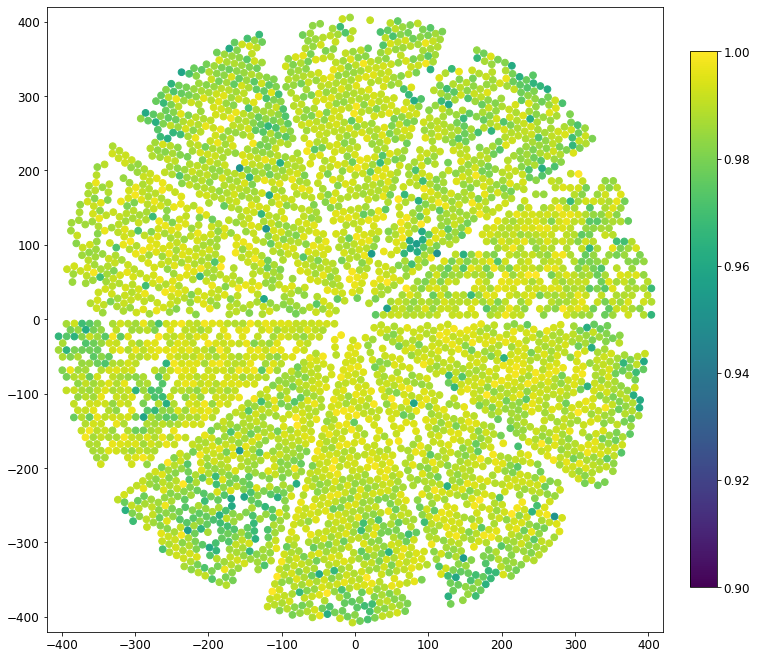

In [24]:
mask = fiberstats['n_tot']>min_fibers
mask &= (~np.in1d(fiberstats['FIBER'], bad_fibers))

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.9, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

In [25]:
np.savetxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', bad_fibers, fmt='%s')

In [26]:
mask = np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate in \"good\" fibers: {:.2f}%'.format(100*np.sum(~cat['q'][~mask])/np.sum(~mask)))
print('Failure rate in \"bad\" fibers: {:.2f}%'.format(100*np.sum(~cat['q'][mask])/np.sum(mask)))

Failure rate in "good" fibers: 1.19%
Failure rate in "bad" fibers: 7.99%
